# Getting started

We'll first create a new pizza ontology using a resolvable W3ID that will be provided through the Ontostart project - https://github.com/micheldumontier/ontostart.

In [1]:
import sys, os
# Locate project root (the directory containing lib/) regardless of CWD
for _p in ['.', '..', '../..']:
    if os.path.isdir(os.path.join(_p, 'lib')):
        os.chdir(_p); sys.path.insert(0, os.getcwd()); break

from lib.helpers import *

# Create our pizza ontology and import SULO
base_iri = "https://w3id.org/ontostart/pizza/"
pizza = get_ontology(base_iri)
# add some metadata about the ontology
pizza.comment = "An ontology about pizzas using SULO."

# save this file
import os
os.makedirs("dist", exist_ok=True)
pizza.save("dist/pizza.owl", format="rdfxml")


Next, we'll import the SULO ontology into the pizza ontology, so we can use SULO's classes and properties in our definitions.

In [2]:
onto_path.append(".")
sulo = get_ontology("dist/sulo.owl").load()
print("Loaded SULO:", sulo.base_iri)
pizza.imported_ontologies.append(sulo)

Loaded SULO: https://w3id.org/sulo/


# OWL Ontologies

The **Web Ontology Language (OWL)** is a formal language for representing knowledge about a domain in a way that both humans and machines can understand. It is a core technology of the Semantic Web, designed to describe what exists in a domain, how things relate, and to enable automated reasoning over that knowledge.

An **OWL ontology** is a formal, machine-readable description of a domain of knowledge, written in OWL, that defines:

* what kinds of things exist (**Class**)
* which specific things exist (**Individuals**)
* how they are related (**Object Properties**)
* and what attributes they have (**Data Properties**)

together with logical rules that constrain and structure this knowledge.



# The nature and composition of a pizza
Let's think about the nature and composition of a **pizza**. A pizza is traditionally a dish of Italian origin, consisting of a flat round base of baked dough (aka pizza crust) that may be covered with a tomato-based sauce, and optionally with herbs, cheese, meat, fish, and/or vegetables. 

The term **pizza** corresponds to **Class** in **OWL**. A **Class** represents a set of individuals having a particular shared attributes. We will denote classes in this tutorial using camel-cased, bold-faced styling: **Pizza** is an **Class**. 

In OWL, **Individuals** represent those things that cannot be instantiated - there is only one of them. For instance, the vegeterian pizza on my table is an **Individual**, while the set of all vegeterian pizzas is a **Class**. 

**Pizza**, **Pizza Crust**, **Pizza Sauce**, and **Pizza Topping** are all kinds of **Food Materials**, and these in turn as kind of SULO **Spatial Objects**. **Spatial Objects** are entities that persist in time, can gain and lose parts, change qualities, and are wholly identifiable at point in their lifetime. 


Let's now formalise our ontology using OwlReady2. We make **class declarations** and define our first **subclass axioms** such that every instance of a subclass is necessarily an instance of a parent class. 

In [3]:
# let's start with a top level category called FoodMaterial to define a pizza and its parts
with pizza:
    class FoodMaterial(sulo.SpatialObject):
        comment = """A food material is a spatial object that is intended for consumption as food."""
    
    class Pizza(FoodMaterial):
        comment = """A pizza is a food material minimally consisting of a pizza crust (baked dough) and optionally topped with 
                    tomatoes or tomato sauce, cheese, and often various other ingredients (such as anchovies, mushrooms, onions, olives, 
                    vegetables, meat, etc.) baked at a high temperature."""

    class PizzaCrust(FoodMaterial):
        comment = """A pizza crust is a food material resulting from the cooking of a dough 
                    and forms the base of a pizza upon which sauce and toppings are added."""

    class PizzaTopping(FoodMaterial):
        comment = """A pizza topping is a food material that is placed on top of a pizza, such as cheese,
                    vegetables, meats, or other ingredients."""

Next, let's check the subclasses of FoodMaterial, and then the ancestors of Pizza

In [4]:
print("Pizza parent class", Pizza.is_a)
print("Pizza ancestors:", [c.name for c in Pizza.ancestors()])
print("FoodMaterial children classes:", list(FoodMaterial.subclasses()))

Pizza parent class [pizza.FoodMaterial]
Pizza ancestors: ['Object', 'Pizza', 'FoodMaterial', 'Thing', 'SpatialObject']
FoodMaterial children classes: [pizza.Pizza, pizza.PizzaCrust, pizza.PizzaTopping]


### **YOUR TURN: Add a new Class**
Add a new class called **PizzaSauce** that is a subclass of **FoodMaterial**. Use the definition "A pizza sauce is a food material used in the preparation of pizza, typically made from tomatoes and various herbs and spices". 


In [5]:
with pizza:
    class PizzaSauce(FoodMaterial):
        comment = locstr("""A pizza sauce is a food material used in the preparation of pizza,
                    typically made from tomatoes and various herbs and spices.""", lang="en")

In [6]:
assert FoodMaterial in PizzaSauce.ancestors(), "PizzaSauce should be a subclass of FoodMaterial"

In [7]:
PizzaSauce.comment.en

['A pizza sauce is a food material used in the preparation of pizza,\n                    typically made from tomatoes and various herbs and spices.']

### **Composition: hasPart**
SULO defines **hasPart** as a fundamental relation between wholes and their parts. A part meaningfully contributes to the whole’s existence, structure, or function. **hasPart** is defined with the computational properties of being **transitive** and **reflexive**:

**Transitive** — if A has-part B, and B has-part C, then A has-part C. A pizza has-part a crust; a crust has-part a cornicione; therefore a pizza has-part a cornicione.

**Reflexive** - A reflexive property holds between every individual and itself — x hasPart x for all x. In other words, every thing is considered a part
  of itself.


In [8]:
# examine the object property characteristics
for prop in [sulo.hasPart]:
    chars = [c.__name__ for c in prop.is_a ]
    print(f"{prop.name}: {chars}")

hasPart: ['ObjectProperty', 'ReflexiveProperty', 'TransitiveProperty', 'contains']


One of the most important parts of a pizza is the **Pizza Crust**. Every pizza must have a crust, and there can be no pizza without a crust. We formalize this in OWL by adding a **SubClass axiom** to **Pizza** using an existential restriction on the **hasPart** property towards **PizzaCrust**. 
 

In [9]:
with pizza:
    Pizza.is_a.append(sulo.hasPart.exactly(1,PizzaCrust))

Next, let's run the automated reasoner to make sure that our ontology is consistent.

In [10]:
ret = safe_call_reasoner(pizza)
if not ret["ok"]:
    print("Reasoner Error: \n", ret["error"])

Reasoner Error: 
 Non-simple property '<https://w3id.org/sulo/hasPart>' or its inverse appears in the cardinality restriction 'ObjectMaxCardinality(1 <https://w3id.org/sulo/hasPart> <https://w3id.org/ontostart/pizza/PizzaCrust>)'.


Well, we see that we get an error from the reasoner, namely that 

```Non-simple property '<https://w3id.org/sulo/hasPart>' or its inverse appears in the cardinality restriction 'ObjectMaxCardinality(1 <https://w3id.org/sulo/hasPart> owl:Thing)'.```

OWL is an expressive language that places some constraints to ensure decidability (that an answer of yes or no can be provided in a reasonable time). One of those restrictions is that you can't place a cardinality restriction on a transitive property - in this case, we can't put the restriction of exactly 1 on **hasPart**. SULO knew you'd want to do this, and therefore has introduced a sub-property called **hasDirectPart**, which is not transitive, and for which you can place the cardinality restriction. 

Let's now remove the problematic axioms and replace **hasPart** with **hasDirectPart**.

In [11]:
with pizza:
      Pizza.is_a.remove(sulo.hasPart.exactly(1, PizzaCrust))
#confirm that it was removed
Pizza.is_a

[pizza.FoodMaterial]

In [12]:
# and now add the new axiom that uses hasDirectPart
with pizza:
    Pizza.is_a.append(sulo.hasDirectPart.exactly(1, PizzaCrust))

In [13]:
# confirmed it was added 
Pizza.is_a

[pizza.FoodMaterial, sulo.hasDirectPart.exactly(1, pizza.PizzaCrust)]

In [14]:
pizza.save(file = "pizza.owl", format = "rdfxml")
results = safe_call_reasoner(pizza)
print("Pizza ontology has", len(results["inconsistent"]), "inconsistent classes")

Pizza ontology has 0 inconsistent classes


Let's now check that PizzaCrust is a direct part of a pizza:

In [15]:
Pizza.hasDirectPart

[pizza.PizzaCrust]

### **YOUR TURN: Add another direct part**

Every pizza needs more than just a crust — it also needs a sauce. Add a subclass axiom that states that every pizza has some pizza sauce.
Modify `Pizza.is_a` to require `sulo.hasDirectPart.some(PizzaSauce)`. Run the reasoner, then call `Pizza.INDIRECT_hasPart`.

> Does `PizzaSauce` appear alongside `PizzaCrust`? What do they have in common that makes both show up?

In [16]:
with pizza:
    Pizza.is_a.append(sulo.hasDirectPart.some(PizzaSauce))

result = safe_call_reasoner(pizza)
print("Consistent:", result["ok"])
print("Pizza.INDIRECT_hasPart:", Pizza.INDIRECT_hasPart)

Consistent: True
Pizza.INDIRECT_hasPart: [pizza.PizzaCrust, pizza.PizzaSauce]


### **Parthood Transitivity**
The outer edge of the pizza crust is referred to as the **Cornicione**. Let's add this class to the ontology, as well as the fact that every crust has a conicione as a part.

In [17]:
with pizza:
    class Cornicione(FoodMaterial):
        comment = """A cornicione is the outer edge of a pizza crust"""
    
    PizzaCrust.is_a.append(sulo.hasDirectPart.some(Cornicione))

In [18]:
PizzaCrust.hasDirectPart

[pizza.Cornicione]

Since **hasDirectPart** is a sub-property of **hasPart**, then a query to retrieve the hasPart relations, will also retrieve the hasDirectPart relations

Using owlready2, we prefix the relation with INDIRECT_ to get the inferred relation.

Now, we should be able to query the ontology for all the parts of a pizza, which should be the PizzaCrust and the Cornicione.

In [19]:
Pizza.INDIRECT_hasPart

[pizza.PizzaCrust, pizza.Cornicione, pizza.PizzaSauce]

### **YOUR TURN: Following a part chain**

`hasPart` is transitive — if X has-part Y and Y has-part Z, then X has-part Z. Let's test this. Define `OliveOil` as a `FoodMaterial` and require that every `TomatoSauce` has `OliveOil` as a direct part. Then call `Pizza.INDIRECT_hasPart`.

> Does `TomatoSauce` appear, even though you never mentioned it in `Pizza`'s axioms? Why?
> What would happen if `hasPart` were not transitive — would `TomatoSauce` still appear?

In [20]:
with pizza:
    class OliveOil(FoodMaterial):
        comment = "The raw mixture of flour, water, and yeast that is baked into a pizza crust."

    PizzaSauce.is_a.append(sulo.hasDirectPart.some(OliveOil))

result = safe_call_reasoner(pizza)
print("Consistent:", result["ok"])
print("Pizza.INDIRECT_hasPart:", Pizza.INDIRECT_hasPart)

Consistent: True
Pizza.INDIRECT_hasPart: [pizza.Cornicione, pizza.PizzaCrust, pizza.PizzaSauce, pizza.OliveOil]


### **Cardinality: hasDirectPart**
Having defined the compositional requirements of a Pizza, we can extend our ontology to capture different kinds of pizzas. 

Let us consider the Four Cheese pizza, which is traditionally made from Mozzarella, Gorgonzola, Parmesan, and Pecorino Romano, but other cheeses could also be used.

We will first define the class of Cheese, and then define our Four Cheese Pizza as a Pizza that exactly contains 4 (different) Cheeses.

In [21]:
with pizza:
    class Cheese(FoodMaterial):
        comment = """A cheese is a food material derived from milk and produced in a wide range of flavors, textures, and forms by coagulation of the milk protein casein."""
    
    class Mozzarella(Cheese):
        comment = """Mozzarella is a traditionally southern Italian cheese made from Italian buffalo's milk by the pasta filata method."""
        
    class Gorgonzola(Cheese):
        comment = """Gorgonzola is a veined Italian blue cheese, made from unskimmed cow's milk."""
    
    class Parmesan(Cheese):
        comment = """Parmesan is a hard, granular cheese named after the producing areas near Parma, Italy."""
        
    class PecorinoRomano(Cheese):
        comment = """Pecorino Romano is a hard, salty Italian cheese, often used for grating, made out of sheep's milk."""
    
    class TraditionalFourCheesePizza(Pizza):
        comment = """A Traditional Four Cheese Pizza is a pizza made with mozzarella, gorgonzola, parmesan, and pecorino romano."""
        equivalent_to = [Pizza
                         & sulo.hasDirectPart.some(Mozzarella)
                         & sulo.hasDirectPart.some(Gorgonzola)
                         & sulo.hasDirectPart.some(Parmesan)
                         & sulo.hasDirectPart.some(PecorinoRomano)]

    class FourCheesePizza(Pizza):
        comment = """A Four Cheese Pizza is a pizza that contains exactly four different types of cheese as toppings."""
        equivalent_to = [Pizza & sulo.hasDirectPart.exactly(4, Cheese)]


In [22]:
in_ancestors(pizza, TraditionalFourCheesePizza, FourCheesePizza) 

TraditionalFourCheesePizza is NOT a subclass of FourCheesePizza


Ok, we were expecting that our traditional four cheese pizza is a four cheese pizza, but we don't find this. The reason is that the reasoner does not know that the four cheeses (Mozzarella, Gorgonzola, Parmesan, Pecorino) are actually different. This behaviour is known as the **Open World Assumption**. That is to say, the reasoner does not assume that things are different (or the same) unless otherwise indicated (either explicitly or by inference). 

To indicate that the four cheeses are in fact different from one another, we have to do two things:
1. use the **AllDisjoint** axioms to indicate that each class is different such that no individual that can be a member of any two in the set.
2. indicate that the traditional four cheese pizza is composed of the four cheeses and no other thing. This is done with a **Universal Cardinality Restriction**

In [23]:
with pizza:
    AllDisjoint([Mozzarella, Gorgonzola, Parmesan, PecorinoRomano])
    TraditionalFourCheesePizza.equivalent_to.pop(0)
    
    TraditionalFourCheesePizza.equivalent_to = equivalent_to = [Pizza
                        & sulo.hasDirectPart.exactly(1, Mozzarella)
                        & sulo.hasDirectPart.exactly(1, Gorgonzola)
                        & sulo.hasDirectPart.exactly(1, Parmesan)
                        & sulo.hasDirectPart.exactly(1, PecorinoRomano)
                        & sulo.hasDirectPart.only(Mozzarella | Gorgonzola | Parmesan | PecorinoRomano)
                        ]

In [24]:
in_ancestors(pizza, TraditionalFourCheesePizza, FourCheesePizza) 

TraditionalFourCheesePizza is a subclass of FourCheesePizza


### **YOUR TURN: Apply the full pattern to a new pizza**

You've now seen the complete recipe for a defined pizza class: cardinality restrictions (`some`, `exactly`, `only`) and `AllDisjoint`.

Define `Prosciutto` as a subclass of `PizzaTopping`, disjoint from all four cheese classes. Then define `ProsciuttoMozzarellaPizza` as a pizza with exactly 1 `Mozzarella` and exactly 1 `Prosciutto` and nothing else as a direct part.

> Before running the reasoner: will it be classified as a `FourCheesePizza`? What does `FourCheesePizza` require — and does `ProsciuttoMozzarellaPizza` meet that?

In [25]:
with pizza:
    class Prosciutto(PizzaTopping):
        comment = "A dry-cured Italian ham used as a pizza topping."

    AllDisjoint([Prosciutto, Mozzarella, Gorgonzola, Parmesan, PecorinoRomano])

    class ProsciuttoMozzarellaPizza(Pizza):
        comment = "A pizza with exactly one mozzarella and one prosciutto topping and nothing else."
        equivalent_to = [Pizza
                         & sulo.hasDirectPart.exactly(1, Mozzarella)
                         & sulo.hasDirectPart.exactly(1, Prosciutto)
                         & sulo.hasDirectPart.only(Mozzarella | Prosciutto)]

in_ancestors(pizza, ProsciuttoMozzarellaPizza, FourCheesePizza)

ProsciuttoMozzarellaPizza is NOT a subclass of FourCheesePizza


Let's save our pizza ontology.

In [26]:
pizza.save(file="dist/pizza-01.owl", format="rdfxml")
print("Saved pizza-01.owl")

Saved pizza-01.owl


Pizza Class hierarchy


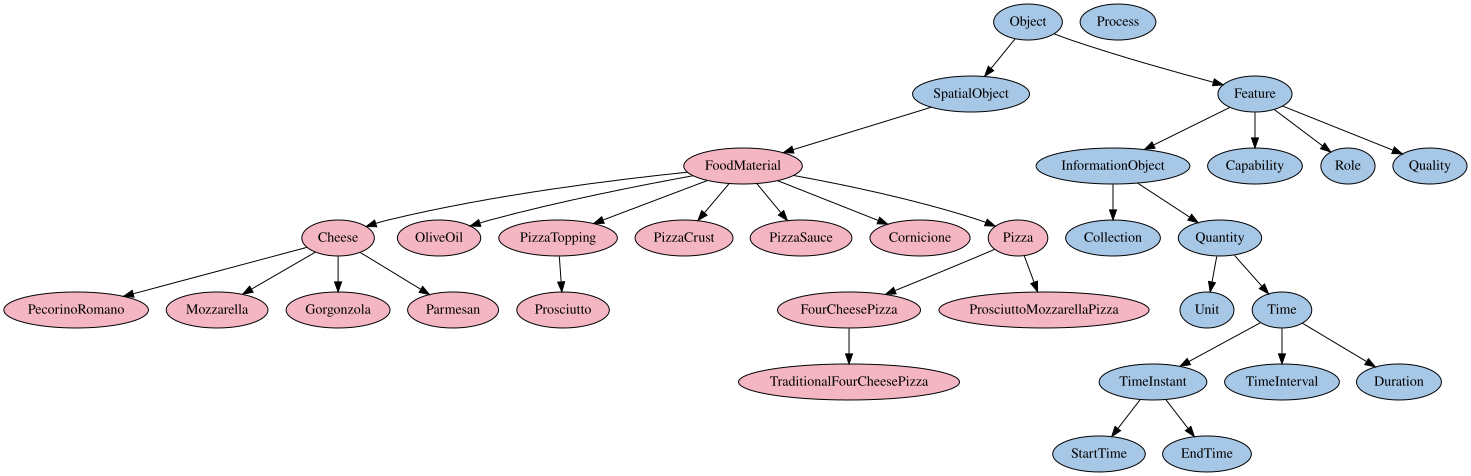

In [27]:
pizza_class_tree = get_color_tree([sulo, pizza])
print("Pizza Class hierarchy")
display(pizza_class_tree)  # Class hierarchy

## Additional Exercises

### Exercise 1 — `MargheritaPizza`
A classic Margherita pizza consists of exactly one `PizzaCrust`, one `PizzaSauce` (tomato), and one `Mozzarella` topping — and nothing else. Define `TomatoSauce` as a subclass of `PizzaSauce`. Then define `MargheritaPizza` as an equivalent class using cardinality and universal restrictions. Run the reasoner and verify that a `MargheritaPizza` is classified as a `FourCheesePizza` — or explain why it is not.


In [28]:
# Exercise 1 — your code here


### Exercise 2 — Crust types
Define three disjoint crust types: `ThinCrust`, `ThickCrust`, and `StuffedCrust` as subclasses of `PizzaCrust`. Define `ThinCrustPizza` as a pizza that `hasDirectPart exactly 1 ThinCrust`. Create a `ThickCrust` individual and assert it `hasDirectPart` of a pizza. Use the reasoner to confirm that pizza cannot be classified as a `ThinCrustPizza`.



In [29]:
# Exercise 2 — your code here


### Exercise 3 — Vegetarian pizza
Define `VegetarianTopping` as a subclass of `PizzaTopping`. Define `PepperTopping`, `MushroomTopping`, `ArtichokTopping` as disjoint subclasses of `VegetarianTopping`. Define `VegetarianPizza` as a `Pizza` whose toppings are `only VegetarianTopping`. Create a `PeperoniTopping` (meat) class and show the reasoner detects inconsistency when you try to classify a pepperoni pizza as vegetarian.



In [30]:
# Exercise 3 — your code here
